# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.


**Условия задачи:**
- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
- Бюджет на разработку скважин в регионе — 10 млрд рублей.
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

Данные синтетические: детали контрактов и характеристики месторождений не разглашаются.

**Установим библиотеки нужной версии:**

In [1]:
!pip install phik

**Импортируем все необходимые библиотеки для исследования:**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import phik
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from numpy.random import RandomState
from sklearn.preprocessing import StandardScaler

## Загрузка и подготовка данных

### Загрузим данные

Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы.

Путь к файлам:
- `'/datasets/geo_data_0.csv'`
- `'/datasets/geo_data_1.csv'`
- `'/datasets/geo_data_2.csv'`

In [3]:
geo_data_0 = pd.read_csv('/datasets/geo_data_0.csv')
geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv')
geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv')

Рассмотрим первые строки, чтобы убедиться в корректном считывании файлов:

In [4]:
geo_data_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [5]:
geo_data_1.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [6]:
geo_data_2.head()

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


Из вывода датафреймов можно сказать, что файлы были прочитаны правильно.

Можно говорить о том, что теперь с такими датафреймами можно работать.

### Предобработка данных

Изучим данные и сделаем выводы. 

#### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафреймах, выведем информацию о них методом `.info()`:

In [7]:
geo_data_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [8]:
geo_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [9]:
geo_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


Проанализировав информацию о датафреймах, можно говорить, что все типы данных **соответствуют** в действительности самим данным - то есть необходимости изменять их тип - **нет**.

#### Проверим наличие пропусков в данных

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [10]:
geo_data_0.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [11]:
geo_data_1.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [12]:
geo_data_2.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Из результатов вывода видно, что пропущенных значений во всех датафреймах нет. Это является *очень хорошим* показателем.

#### Проверим данные на наличие дубликатов

После проверки датафрейма на наличие пропусков, проверим его на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [13]:
geo_data_0.duplicated().sum()

0

In [14]:
geo_data_1.duplicated().sum()

0

In [15]:
geo_data_2.duplicated().sum()

0

В результате наблюдаем, что *явных* дубликатов нет.

Теперь проверим данные на наличие *неявных* дубликатов, которые также могут встретиться. Для этого необходимо будет проверить все категориальные столбцы с данными. Так как столбцов с данными всего один - `'id'`, то для оптимизации решения сделаем следующее: посчитаем количество идентификаторов в столбце `'id'` датафреймов и после проанализируем результаты. Применять в данном случае метод `.unique()` нерационально, так как объём данных слишком большой - `100000`.

In [16]:
geo_data_0['id'].value_counts()

74z30    2
Tdehs    2
bsk9y    2
HZww2    2
TtcGQ    2
        ..
MBm9F    1
HgBof    1
rzahq    1
QFZFm    1
heyUu    1
Name: id, Length: 99990, dtype: int64

In [17]:
geo_data_1['id'].value_counts()

5ltQ6    2
wt4Uk    2
LHZR0    2
bfPNe    2
yYIfY    1
        ..
U4V6o    1
sT18m    1
YSrN9    1
IiD0w    1
vXvdk    1
Name: id, Length: 99996, dtype: int64

In [18]:
geo_data_2['id'].value_counts()

Vcm5J    2
xCHr8    2
VF7Jo    2
KUPhW    2
yVA8Q    1
        ..
6uenu    1
3rgmg    1
p9CUN    1
twK2u    1
UWrru    1
Name: id, Length: 99996, dtype: int64

Из результатов подсчёта количества одинаковых `'id'` получили, что некоторые встречаются 2 раза.

Посмотрим срез данных в каждом датафрейме при таком `'id'`:

In [19]:
geo_data_0.query('id == "fiKDv"')

,id,f0,f1,f2,product
16633,fiKDv,0.157341,1.028359,5.585586,95.817889
90815,fiKDv,0.049883,0.841313,6.394613,137.346586


In [20]:
geo_data_1.query('id == "wt4Uk"')

,id,f0,f1,f2,product
47591,wt4Uk,-9.091098,-8.109279,-0.002314,3.179103
82873,wt4Uk,10.259972,-9.376355,4.994297,134.766305


In [21]:
geo_data_2.query('id == "KUPhW"')

,id,f0,f1,f2,product
45404,KUPhW,0.231846,-1.698941,4.990775,11.716299
55967,KUPhW,1.211150,3.176408,5.543540,132.831802


Видно, что `'id'` - одинаковый, **но** разные признаки точек и объём запасов в скважине. Из практики следует, что участок бурения может быть один и тот же, однако глубина и толщина залегания нефтяного пласта может быть разной, следовательно и показателей для одной и той же скважины может быть несколько. 

Также отметим, что **данные синтетические**: детали контрактов и характеристики месторождений *не разглашаются* - поэтому примем, что каждая скважина *уникальна*. В связи с этим **не будем** проводить удаление найденных повторов. 

**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- изучили основную информацию о датафреймах
- определили, что типы данных соответствуют действительности
- определили, что названия столбцов имеют правильную запись
- проверили и проанализировали данные на наличие дубликатов как явных, так и неявных

### Исследовательский анализ данных

Исследуем признаки и сделаем выводы о том, как их нужно подготовить.

**Проведём статистический анализ всех признаков**

Ранее можно было заметить, что в датафреймах присутствуют только количественные переменные (`'id'` - можно считать идентификатором и не считать его категориальным признаком). В связи с эти требуется обработка данных данного типа.

#### Рассмотрим количественные переменные

Воспользуемся методом `.describe()` для того, что вывести все признаки количественных переменных в датафреймах.

In [22]:
geo_data_0.drop(columns='id').describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


In [23]:
geo_data_1.drop(columns='id').describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [24]:
geo_data_2.drop(columns='id').describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


Из представленных описательных характеристик можно говорить о том, что данные, в принципе, довольно хорошо представлены. Проверим данные на наличие выбросов построением диаграммы размаха("ящика с усами") и сделаем выводы о данных.

Для упрощения работы создадим функцию `counting_param()`, которая будет визуализировать гистограмму и "ящик с усами" в зависимости от передаваемых параметров:

In [25]:
# функция визуализации графиков
# в функцию передаётся: датафрейм, список столбцов датафрейма, название оси Х, название оси У
def counting_param(dataframe, columns_list, measure_x, measure_y):
    for i,j in zip(columns_list, measure_x):
        plt.figure(figsize=(20, 15))
        # Вывод графиков
        plt.subplot(2, 2, 1)
        # Шаблон для построения гистограммы
        dataframe[i].plot(kind='hist', bins=250, grid=True)
        plt.xlabel(j)
        plt.ylabel(measure_y)
        plt.subplot(2, 2, 2)
        # Шаблон для построения "ящика с усами"
        dataframe.boxplot(column=[i])
        plt.xticks([])
        plt.ylabel(j)

Применим написанную функцию `counting_param()`:

In [26]:
geo_data_title_list = (['Oбъём запасов в скважине (тыс. баррелей)'])

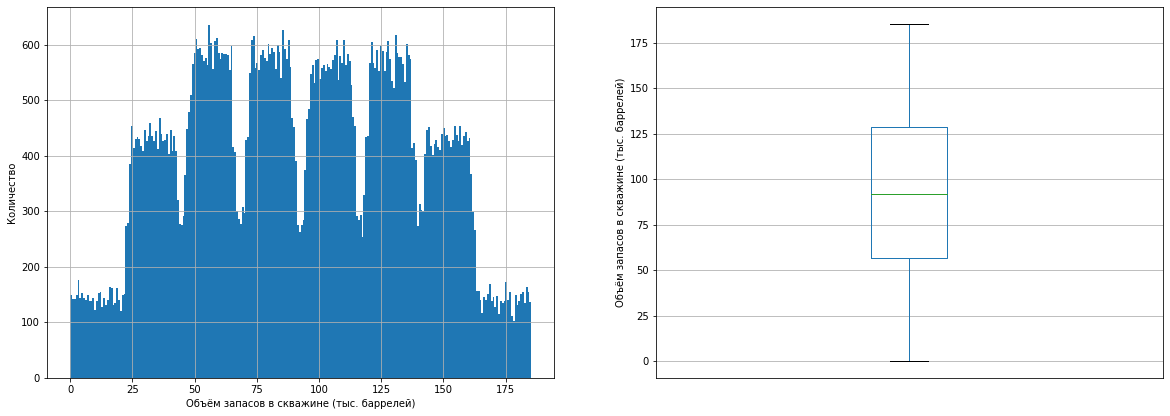

In [27]:
counting_param(geo_data_0, ['product'], geo_data_title_list,'Количество')

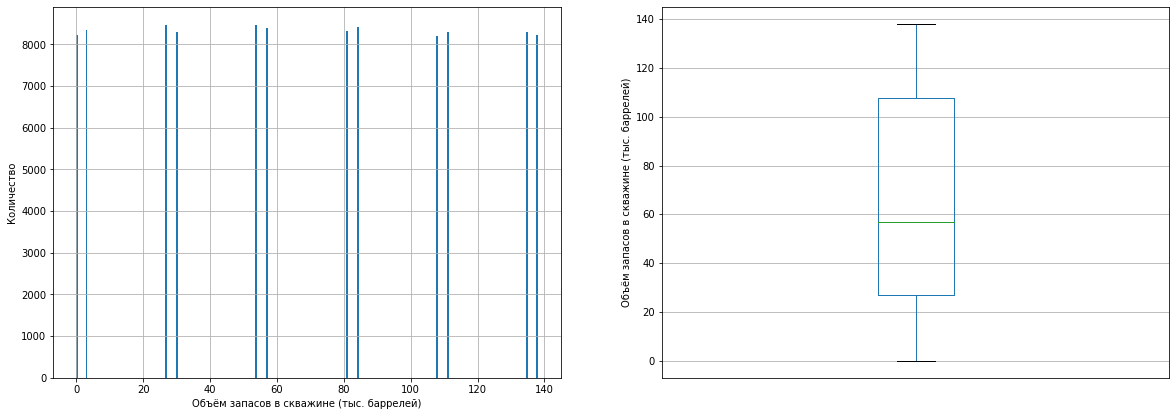

In [28]:
counting_param(geo_data_1, ['product'], geo_data_title_list,'Количество')

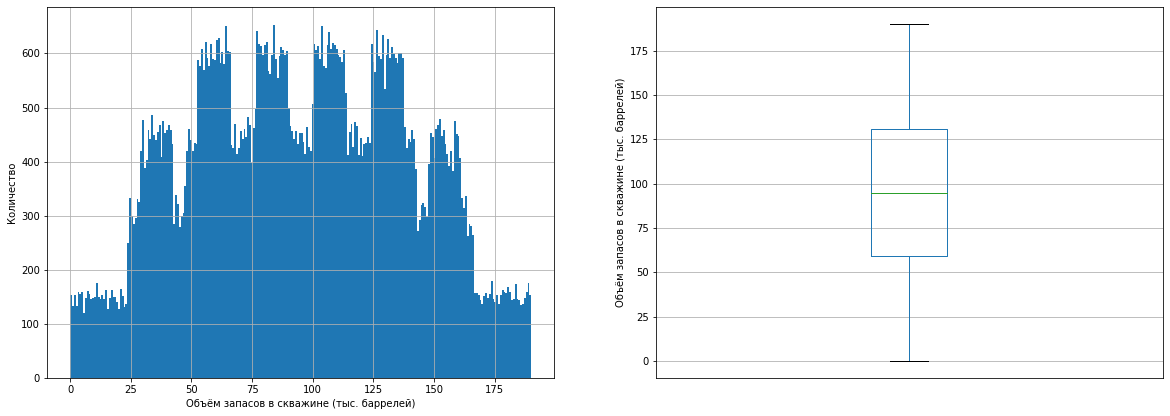

In [29]:
counting_param(geo_data_2, ['product'], geo_data_title_list,'Количество')

Из представленных гистограмм и диаграмм размахов видно следующее: выбросов в данных нет, что является очень хорошим показателем.

Из преставленных гистограмм можно говорить о следующем: распределение целевых признаков в каждом регионе уникально и аномально - то есть не похоже ни на одно из известных нормальных распределений. Отдельное внимание стоит обратить на второй регион, так как там получился график сильно отличающийся от первого и третьих регионов; возможно нужна проверка на корректность переданных нам данных.

#### Корреляционный анализ

**Проведём корреляционный анализ признаков в датасетах**

Изучим взаимосвязь между признаками в датафреймах - хорошим решением будет использовать коэффициент корреляции  𝜙𝐾, это передовой способ вычисления коэффициентов корреляции для любых типов признаков и не требует предварительного кодирования, этот коэффициент показывает не только линейные связи, но и нелинейные, а также подходит для больших наборов данных - `phik` обладает хорошей масштабируемостью, что позволяет использовать его для анализа больших наборов данных без серьезного снижения производительности. Для этого воспользуемся методом `.phik_matrix()`, который возвращает коэффициенты корреляции 𝜙𝐾; перед этим удалим столбец `'id'`, так как он лишь показывает уникальный идентификатор покупателя, который никак не связан с остальными столбцами. 

In [30]:
def phik_matr(dataframe, delete_list, interval_cols, title_plot):
    phiK_mat = dataframe.drop(columns=delete_list).phik_matrix(interval_cols=interval_cols)
    plt.figure(figsize=(15, 10))
    sns.heatmap(phiK_mat, annot=True, fmt='.3f', cmap='coolwarm')
    plt.xticks(rotation=0)
    plt.title(title_plot)
    plt.show()

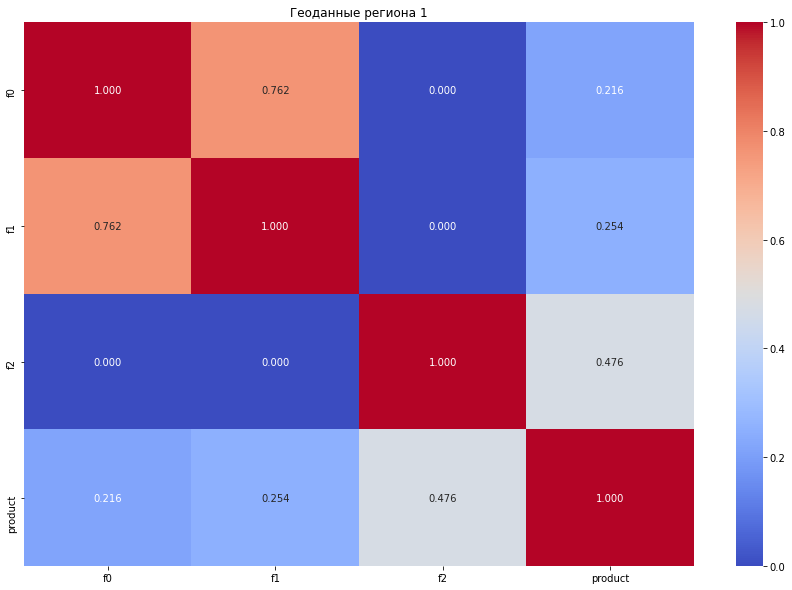

In [31]:
phik_matr(geo_data_0, ['id'], ['f0', 'f1', 'f2', 'product'], 'Геоданные региона 1')

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: есть коррелирующие и некоррелирующие величины. Из тепловой карты наглядно видно: 
- **высокая** связь: `'f0'`-`'f1'`
- **умеренная** связь: `'f2'`-`'product'`
- остальные же признаки имеют **слабую** связь или её вообще нет 

Из графика можно сказать, что говорить о **мультиколлениарности** тут нельзя.

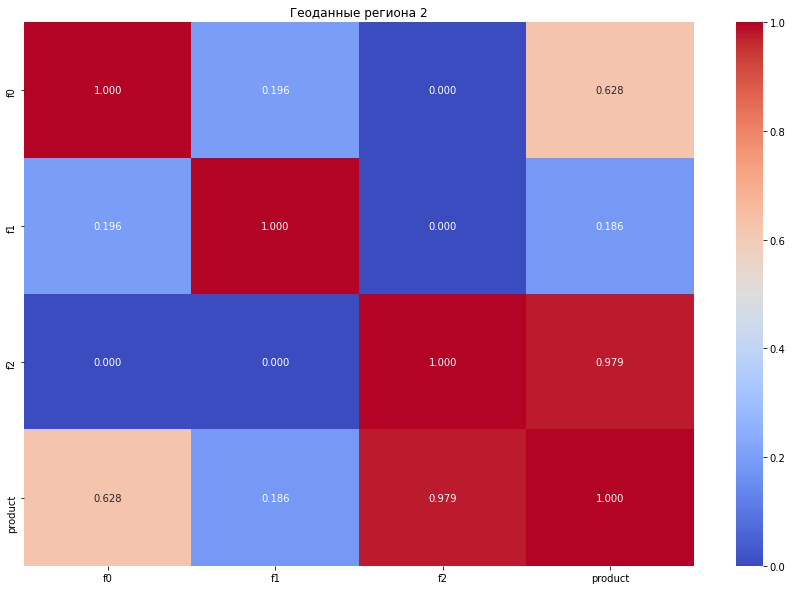

In [32]:
phik_matr(geo_data_1, ['id'], ['f0', 'f1', 'f2', 'product'], 'Геоданные региона 2')

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: есть коррелирующие и некоррелирующие величины. Из тепловой карты наглядно видно: 
- **высокая** связь: `'f2'`-`'product'`
- **заметная** связь: `'f0'`-`'product'`
- остальные же признаки имеют **слабую** связь или её вообще нет 

Из графика можно сказать, что **мультиколлениарности** между исходными признаками нет.


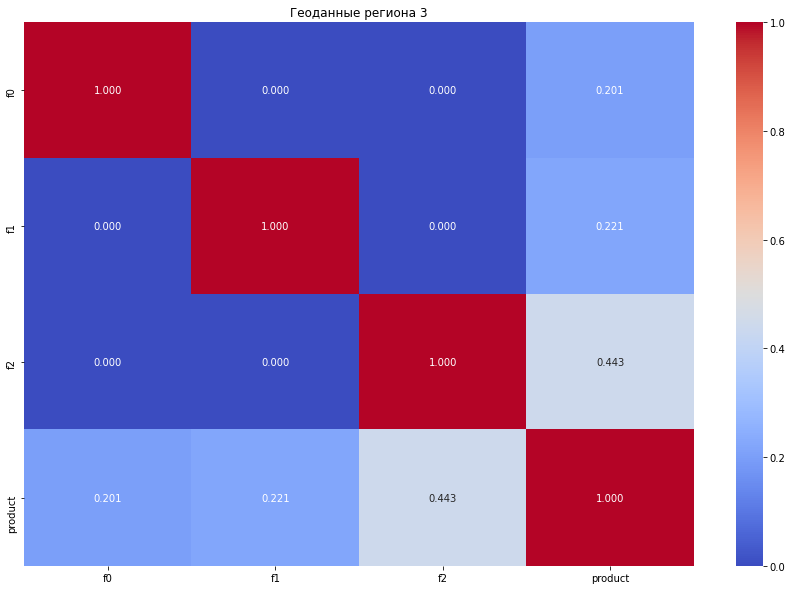

In [33]:
phik_matr(geo_data_2, ['id'], ['f0', 'f1', 'f2', 'product'], 'Геоданные региона 3')

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: есть коррелирующие и некоррелирующие величины. Из тепловой карты наглядно видно: 
- **умеренная** связь: `'f2'`-`'product'`
- остальные же признаки имеют **слабую** связь или её вообще нет 

Из графика можно сказать, что говорить о **мультиколлениарности** между исходными признаками нельзя.

**Промежуточный вывод:**

В результате исследования количественных признаков было получено следующее:
- были проанализированы гистограммы и диаграммы размаха во всех датафреймах
- было проведено исследование графиков распределения - выявлены аномальные распределения графиков во всех трех регионах

В результате исследования корреляционного анализа было получено следующее:
- построили тепловую карту матрицы корреляционных значений и проанализировали 
- сделали выводы о взаимосвязи признаков
- проанализировали и определили, что между исходными признаками нет мультиколлениарности

### Подготовка данных

Так как столбец `'id'` - просто даёт уникальный номер и никак не влияет на обучение и результат модели, то удалим его, сделав новым индексом в датафрейме, и подготовим данные к дальнейшему обучению:

In [34]:
geo_data_0 = geo_data_0.set_index('id')
geo_data_1 = geo_data_1.set_index('id')
geo_data_2 = geo_data_2.set_index('id')

Разделим данные всех трёх датафреймов на исходные и целевой признаки:

In [35]:
X_geo_data_0 = geo_data_0.drop('product', axis=1)
X_geo_data_1 = geo_data_1.drop('product', axis=1)
X_geo_data_2 = geo_data_2.drop('product', axis=1)

In [36]:
y_geo_data_0 = geo_data_0['product']
y_geo_data_1 = geo_data_1['product']
y_geo_data_2 = geo_data_2['product']

### Сделаем выводы о данных

В результате загрузки и подготовки данных были сделаны и получены следующие результаты:
- Загрузка данных:
    - считали CSV-файлы 
- Предобработка данных:
    - изучили основную информацию о датафреймах
    - определили, что типы данных соответствуют действительности
    - определили, что названия столбцов имеют правильную запись
    - проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- Исследовательский анализ данных:
    - В результате исследования количественных признаков были получены следующие результаты:
       - были проанализированы гистограммы и диаграммы размаха во всех датафреймах
       - было проведено исследование графиков распределения - выявлены аномальные распределения графиков во всех трех регионах

    - В результате исследования корреляционного анализа были получены следующие результаты:
        - построили тепловую карту матрицы корреляционных значений и проанализировали 
        - сделали выводы о взаимосвязи признаков
        - проанализировали и определили, что между исходными признаками нет мультиколлениарности
        
- Подготовка данных:
    - провели разделение на входные и целевые признаки для тренировочных и валидационных данных

## Обучение и проверка модели

Обучим и проверим модель для каждого региона:
- Разобьём данные на обучающую и валидационную выборки в соотношении 75:25.
- Обучим модель и сделаем предсказания на валидационной выборке.
- Сохраним предсказания и правильные ответы на валидационной выборке.
- Напечатаем на экране средний запас предсказанного сырья и RMSE модели.
- Проанализируем результаты.

### Обучение линейной модели

В связи с тем, что у нас три датафрейма, которые схожи друг с другом по описанию, то для оптимизации процесса будет удобнее написать функцию, которая обучает модель и выполняет все необходимые действия. Напишем функцию `learning()`:

In [37]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

In [38]:
def learning(X_dataframe, y_dataframe, RANDOM_STATE, TEST_SIZE, region):
    # разделение на тренировочную и валидационную выборки
    X_dataframe_train, X_dataframe_valid, y_dataframe_train, y_dataframe_valid = train_test_split(X_dataframe, y_dataframe,
        random_state=RANDOM_STATE, test_size=TEST_SIZE)
    
    # стандартизируем количественные данные с помощью StandardScaler()
    scaler = StandardScaler()
    
    # столбцы с количественными данными
    num_col = ['f0', 'f1', 'f2']
    
    X_dataframe_train[num_col] = scaler.fit_transform(X_dataframe_train[num_col])
    X_dataframe_valid[num_col] = scaler.transform(X_dataframe_valid[num_col])
    
    # обучаем модель и получаем предсказанный целевой признак
    lin_model = LinearRegression()
    lin_model.fit(X_dataframe_train, y_dataframe_train)
    y_pred = lin_model.predict(X_dataframe_valid)
    
    # RMSE модели
    RMSE = mean_squared_error(y_dataframe_valid, y_pred, squared=False)
    
    # Определим средний запас сырья в данном регионе и RMSE модели
    print(f'Средний предсказанный запас сырья в {region} регионе:', y_pred.mean())
    print('RMSE модели:', RMSE)
    
    # Создадим датафрейм с реальными и предсказанными результатами
    dataframe_targets = pd.DataFrame(columns=['correct_valid', 'predict'])
    dataframe_targets['correct_valid'] = y_dataframe_valid
    dataframe_targets['predict'] = y_pred
    
    return dataframe_targets, y_pred.mean(), y_dataframe_valid.mean()

Вызовем созданную нами функцию к каждому из датафреймов:

In [39]:
geo_data_0_dataframe_targets, geo_data_0_pred_mean, geo_data_0_valid_mean = learning(X_geo_data_0, y_geo_data_0, RANDOM_STATE, TEST_SIZE, '1ом')

Средний предсказанный запас сырья в 1ом регионе: 92.39879990657768
RMSE модели: 37.75660035026169


/tmp/ipykernel_385/2782955281.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_dataframe_train[num_col] = scaler.fit_transform(X_dataframe_train[num_col])
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [40]:
geo_data_1_dataframe_targets, geo_data_1_pred_mean, geo_data_1_valid_mean = learning(X_geo_data_1, y_geo_data_1, RANDOM_STATE, TEST_SIZE, '2ом')

Средний предсказанный запас сырья в 2ом регионе: 68.7128780391376
RMSE модели: 0.8902801001028846


/tmp/ipykernel_385/2782955281.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_dataframe_train[num_col] = scaler.fit_transform(X_dataframe_train[num_col])
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [41]:
geo_data_2_dataframe_targets, geo_data_2_pred_mean, geo_data_2_valid_mean = learning(X_geo_data_2, y_geo_data_2, RANDOM_STATE, TEST_SIZE, '3eм')

Средний предсказанный запас сырья в 3eм регионе: 94.77102387765939
RMSE модели: 40.145872311342174


/tmp/ipykernel_385/2782955281.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_dataframe_train[num_col] = scaler.fit_transform(X_dataframe_train[num_col])
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

Из полученного датафрейма запишем предсказанные и валидационные результаты в новые переменные для упрощения работы в дальнейшем исследовании:

In [42]:
geo_data_0_pred = geo_data_0_dataframe_targets['predict']
geo_data_0_valid = geo_data_0_dataframe_targets['correct_valid']
geo_data_1_pred = geo_data_1_dataframe_targets['predict']
geo_data_1_valid = geo_data_1_dataframe_targets['correct_valid']
geo_data_2_pred = geo_data_2_dataframe_targets['predict']
geo_data_2_valid = geo_data_2_dataframe_targets['correct_valid']

**Промежуточный вывод:**

В результате обучения и проверки модели были получены следующие результаты:
- были проанализированы данные датафреймов
- была создана функция `learning()`, которая делит датасет на выборки, обучает модель и предсказывает целевой признак, а также вычисляет метрику RMSE для выбранной модели
- определили, что *наименьший* RMSE во втором регионе, который равен `0.8902801`; это очень хороший результат, так как чем меньше значение метрики RMSE, тем лучше модель, потому что меньшее значение RMSE указывает на то, что предсказания модели ближе к фактическим значениям
- определили, что *наибольший* средний запас сырья в третьем регионе - `94.77102387`, а также можно сказать, что первый регион тоже достаточно близок к такому значению - `92.3987999`
- регионы с наибольшими средними запасами сырья имеют большую метрику RMSE, чем с наименьшим 

## Подготовка к расчёту прибыли

Подготовимся к расчёту прибыли:
- Все ключевые значения для расчётов сохраним в отдельных переменных.
- Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины. Сравним полученный объём сырья со средним запасом в каждом регионе. 
- Напишем выводы по этапу подготовки расчёта прибыли.

Напишем функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели:
- Выберем скважины с максимальными значениями предсказаний. 
- Просуммируем целевое значение объёма сырья, соответствующее этим предсказаниям.
- Рассчитаем прибыль для полученного объёма сырья.

Определим константы, которые понадабятся в дальнейшем:

In [43]:
BUDGET = 10000000000
SEARCH_POINTS = 500
BEST_POINTS = 200
ONE_UNIT_PRICE = 450000

Определим достаточный объём сырья для безубыточной разработки новой скважины:

In [44]:
BENEFICIAL_VOLUME = (BUDGET/BEST_POINTS)/ONE_UNIT_PRICE
print('Достаточный объём сырья для безубыточной разработки новой скважины равен ', round(BENEFICIAL_VOLUME,3), 'тыс. баррелей')

Достаточный объём сырья для безубыточной разработки новой скважины равен  111.111 тыс. баррелей


Сравним данный достаточный объём с ранее полученными результатами по регионам:

In [45]:
region_pred_mean = [geo_data_0_pred_mean, geo_data_1_pred_mean, geo_data_2_pred_mean]
region_valid_mean = [geo_data_0_valid_mean, geo_data_1_valid_mean, geo_data_2_valid_mean]
region = ['1ом', '2ом', '3ем']

for reg, pred_mean, valid_mean in zip(region, region_pred_mean, region_valid_mean):
    print(f'В {reg} регионе средний запас сырья равен {pred_mean} тыс. баррелей')
    print(f'Разница между достаточным и средним предсказанным объёмами сырья равна {BENEFICIAL_VOLUME - pred_mean} тыс. баррелей')
    print(f'Разница между достаточным и средним валидационным объёмами сырья равна {BENEFICIAL_VOLUME - valid_mean} тыс. баррелей')
    print()

В 1ом регионе средний запас сырья равен 92.39879990657768 тыс. баррелей
Разница между достаточным и средним предсказанным объёмами сырья равна 18.712311204533435 тыс. баррелей
Разница между достаточным и средним валидационным объёмами сырья равна 18.785154740267245 тыс. баррелей

В 2ом регионе средний запас сырья равен 68.7128780391376 тыс. баррелей
Разница между достаточным и средним предсказанным объёмами сырья равна 42.39823307197351 тыс. баррелей
Разница между достаточным и средним валидационным объёмами сырья равна 42.38573036388367 тыс. баррелей

В 3ем регионе средний запас сырья равен 94.77102387765939 тыс. баррелей
Разница между достаточным и средним предсказанным объёмами сырья равна 16.340087233451726 тыс. баррелей
Разница между достаточным и средним валидационным объёмами сырья равна 15.960112039391504 тыс. баррелей



Из полученного объёма для безубыточной разработки можно говорить о том, что у третьего региона, в котором лучший средний запас сырья - `94.77102387`, не хватает около 16 позиций(что на валидационных, что на предсказанных значениях), чтобы быть безубыточным, причём у первого и второго ситуации еще хуже, так как их средние запасы сырья ещё меньше; в связи с этим можно сказать, что *разработка* новой скажины весьма *рискована*. 

Напишем функцию для расчёта прибыли:

In [46]:
def profit_region(region, dataframe_valid, dataframe_pred, comment=None):
    # Отбор 200 лучших для разработки точек месторождений
    best_selection = dataframe_pred.sort_values(ascending=False).head(200)
    
    # общий объём с выбранных точек
    total_volume = dataframe_valid[best_selection.index].sum()
    
    # прибыль с общего объёма сырья
    total_income = total_volume * ONE_UNIT_PRICE
    
    # выручка с региона
    profit = total_income - BUDGET
    
    if (comment == 'yes'):
        print(f'Изучение {region} региона:')
        print(f'Выделенный бюджет на разработку скважин в регионе: {BUDGET:,.0f} рублей')
        print(f'Общий объём с 200 лучших точек: {total_volume:,.3f} тыс. баррелей')
        print(f'Общая прибыль с общего объёма сырья {total_income:,.3f} рублей')
        print(f'Прибыль от выбранных лучших скважин: {profit:,.3f} рублей') 
        
    return profit

**Промежуточный вывод:**

В результате подготовки к расчёту прибыли были получены следующие результаты:
- определены основные константы для работы и нахождения экономических параметров
- определен достаточный объём сырья для безубыточной разработки новой скважины - 111.111 тыс. баррелей
- проведено сравнение достаточного объёма сырья со средним в каждом регионе
- определено, что для безубыточной разработки не хватает минимум 16 позиций по добыче сырья
- выдвинуто предположение, что разработка новой скажины в исследуемых регионах рискована
- написана функция для расчёта прибыли

## Расчёт прибыли и рисков

Посчитаем риски и прибыль для каждого региона:
- Применем технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли.
- Найдём среднюю прибыль, 95%-й доверительный интервал и риск убытков. Убыток — это отрицательная прибыль.
- Напишем выводы: предложите регион для разработки скважин и обоснуйте выбор.

С помощью функции `profit_region()`, написанной в пункте 3, рассчитаем прибыль в каждом регионе и сравним их:

In [47]:
profit_region('1ого', geo_data_0_valid, geo_data_0_pred, 'yes')

Изучение 1ого региона:
Выделенный бюджет на разработку скважин в регионе: 10,000,000,000 рублей
Общий объём с 200 лучших точек: 29,686.980 тыс. баррелей
Общая прибыль с общего объёма сырья 13,359,141,114.462 рублей
Прибыль от выбранных лучших скважин: 3,359,141,114.462 рублей


3359141114.462179

In [48]:
profit_region('2ого', geo_data_1_valid, geo_data_1_pred, 'yes')

Изучение 2ого региона:
Выделенный бюджет на разработку скважин в регионе: 10,000,000,000 рублей
Общий объём с 200 лучших точек: 27,589.082 тыс. баррелей
Общая прибыль с общего объёма сырья 12,415,086,696.682 рублей
Прибыль от выбранных лучших скважин: 2,415,086,696.682 рублей


2415086696.681511

In [49]:
profit_region('3eго', geo_data_2_valid, geo_data_2_pred, 'yes')

Изучение 3eго региона:
Выделенный бюджет на разработку скважин в регионе: 10,000,000,000 рублей
Общий объём с 200 лучших точек: 27,996.826 тыс. баррелей
Общая прибыль с общего объёма сырья 12,598,571,759.374 рублей
Прибыль от выбранных лучших скважин: 2,598,571,759.374 рублей


2598571759.374111

Из полученных результатов видно, что наиболее прибыльным является первый регион с прибылью около 3.4 млрд. рублей.

Теперь с помощью техники *Bootstrap* сделаем 1000 выборок, чтобы найти распределение прибыли для каждого региона по отдельности. Напишем функцию `bootstrap_research()`, которая будет делать случайную выборку, определит среднюю прибыль, 95%-й доверительный интервал и риск убытков(убыток — это отрицательная прибыль):

In [50]:
def bootstrap_research(region, target_data, predict_data):
    state = RandomState(123456)
    selections = []
    
    # выборка в 1000 элементов
    for i in range(1000):
        target_subsample = target_data.sample(n=SEARCH_POINTS, replace=True, random_state=state)
        probs_subsample = predict_data[target_subsample.index]
        profits = profit_region(region, target_subsample, probs_subsample)
        selections.append(profits)

    selections = pd.Series(selections)
    
    # средняя прибыль
    mean_profit_region = selections.mean()
    
    # нижний и верхний квантили
    lower = selections.quantile(0.025)
    upper = selections.quantile(0.975)
    risk = (len(selections[selections < 0]) / len(selections))
    
    print(f'Исследование {region} региона:')
    print(f'Средняя прибыль: {mean_profit_region:,.3f} рублей')
    print(f'Нижняя граница: {lower:,.3f} рублей')
    print(f'Верхняя граница: {upper:,.3f} рублей')
    print(f'Риск убытка: {risk:.2%} \n')
    
    # гистограмма распределения прибыли с квантилями
    plt.figure(figsize=(15, 10))
    selections.plot(kind='hist', bins=50, grid=True, label = 'Прибыль(в рублях)')
    plt.axvline(x = lower, color = 'r', linestyle = '--', label = 'Нижний квантиль(2.5%)')
    plt.axvline(x = upper, color = 'r', linestyle = '-.', label = 'Верхний квантиль(97.5%)')
    plt.xlabel('Выручка (в рублях)')
    plt.ylabel('Количество')
    plt.title('Распределение прибыли по региону')
    plt.legend(bbox_to_anchor=(1.25, 0.6))

Применим функцию `bootstrap_research()` для исследования каждого региона:

Исследование 1ого региона:
Средняя прибыль: 612,991,306.107 рублей
Нижняя граница: 30,939,215.952 рублей
Верхняя граница: 1,262,629,945.124 рублей
Риск убытка: 2.10% 



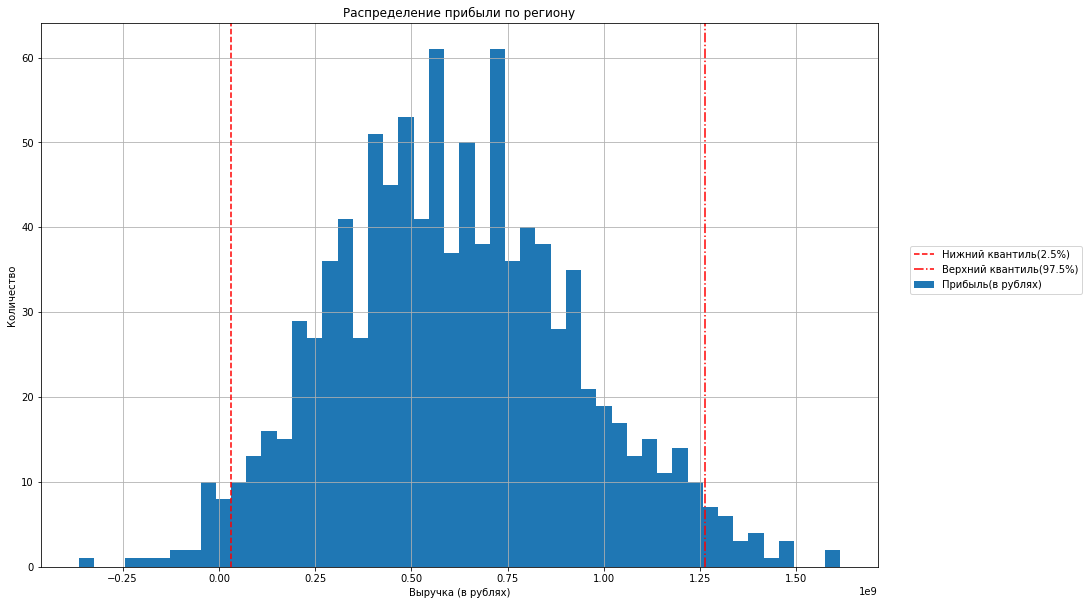

In [51]:
bootstrap_research('1ого', geo_data_0_valid, geo_data_0_pred)

Исследование 2ого региона:
Средняя прибыль: 641,246,166.387 рублей
Нижняя граница: 152,976,729.764 рублей
Верхняя граница: 1,187,608,754.376 рублей
Риск убытка: 0.60% 



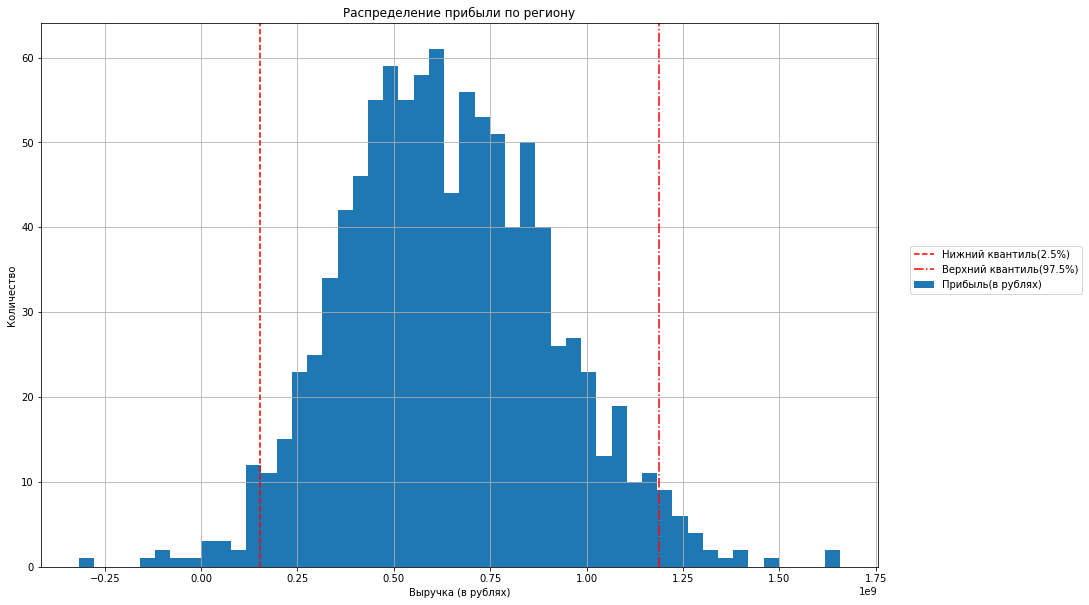

In [52]:
bootstrap_research('2ого', geo_data_1_valid, geo_data_1_pred)

Исследование 3его региона:
Средняя прибыль: 581,667,512.588 рублей
Нижняя граница: 8,107,720.340 рублей
Верхняя граница: 1,248,482,921.207 рублей
Риск убытка: 2.30% 



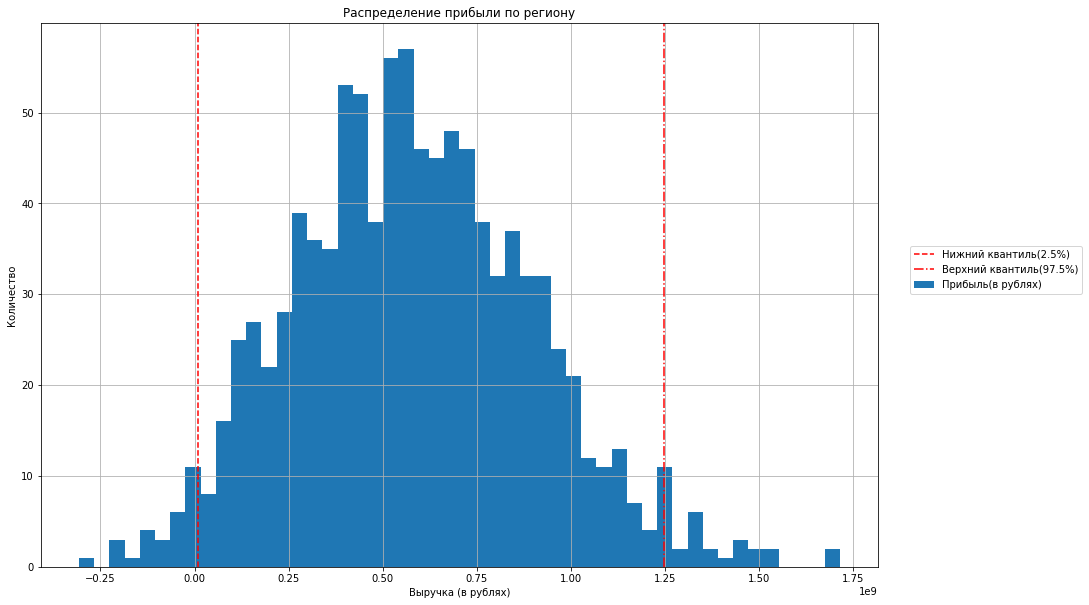

In [53]:
bootstrap_research('3его', geo_data_2_valid, geo_data_2_pred)

Исходя из результатов проведенного исследования, можно говорить о том, что *наименее* рискованным является **второй регион** с процентом риска убытка равным `0.60%`, что меньше согласно поставленной нам вероятности убытков в `2.5%` , а также в нём *наибольшая* средняя прибыль прибыль по сравнению с остальными регионами - около `641` млн. рублей, что тоже соответствует требованием исследования.

**Промежуточный вывод:**

В результате расчёта прибыли и рисков были получены следующие результаты:
- написали функцию `bootstrap_research()`, которая с помощью техники *Bootstrap* будет делать случайную выборку, определять среднюю прибыль, 95%-й доверительный интервал и риск убытков
- применили функцию `bootstrap_research()` и проанализировали результаты 
- из анализа результатов и гистограмм распределения предположили регион для разработки скважин - второй регион

## Общий вывод по исследованию

Сформулируем общий вывод из проведенного нами исследования:

- Загрузка данных:
    - считали CSV-файлы 
- Предобработка данных:
    - изучили основную информацию о датафреймах
    - определили, что типы данных соответствуют действительности
    - определили, что названия столбцов имеют правильную запись
    - проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- Исследовательский анализ данных:
    - В результате исследования количественных признаков были получены следующие результаты:
       - были проанализированы гистограммы и диаграммы размаха во всех датафреймах
       - было проведено исследование графиков распределения - выявлены аномальные распределения графиков во всех трех регионах

    - В результате исследования корреляционного анализа были получены следующие результаты:
        - построили тепловую карту матрицы корреляционных значений и проанализировали 
        - сделали выводы о взаимосвязи признаков
        - проанализировали и определили, что между исходными признаками нет мультиколлениарности
        
- Подготовка данных:
    - провели разделение на входные и целевые признаки для тренировочных и валидационных данных
    
- Обучение моделей:
    - была обучена линейная модель (требование заказчика)
    - были проанализированы данные датафреймов
    - была создана функция `learning()`, которая делит датасет на выборки, обучает модель и предсказывает целевой признак, а также вычисляет метрику *RMSE* для выбранной модели
    - определили, что *наименьший* RMSE во втором регионе, который равен `0.8902801`; это очень хороший результат, так как чем меньше значение метрики RMSE, тем лучше модель, потому что меньшее значение RMSE указывает на то, что предсказания модели ближе к фактическим значениям
    - определили, что *наибольший* средний запас сырья в третьем регионе - `94.77102387`, а также можно сказать, что первый регион тоже достаточно близок к такому значению - `92.3987999`
    - регионы с наибольшими средними запасами сырья имеют большую метрику RMSE, чем с наименьшим 

- Подготовка к расчёту прибыли:
    - определены основные константы для нахождения экономических параметров
    - определен достаточный объём сырья для безубыточной разработки новой скважины - `111.111` тыс. баррелей
    - проведено сравнение достаточного объёма сырья со средним в каждом регионе
    - определено, что для безубыточной разработки не хватает *минимум* 16 позиций по добыче сырья
    - выдвинуто предположение, что разработка новой скажины в исследуемых регионах рискована
    - написана функция `profit_region()` для расчёта прибыли
- Расчёт прибыли и рисков:
    - написали функцию `bootstrap_research()`, которая с помощью техники *Bootstrap* будет делать случайную выборку, определять среднюю прибыль, 95%-й доверительный интервал и риск убытков
    - применили функцию `bootstrap_research()` и проанализировали результаты 
    - из анализа результатов и гистограмм распределения предложили регион для разработки скважин - второй регион
    
Исходя из результатов проведенного исследования, можно говорить о том, что *наименее* рискованным является **второй регион** с процентом риска убытка равным `0.60%`, что меньше согласно поставленной нам вероятности убытков в `2.5%` , а также в нём *наибольшая* средняя прибыль прибыль по сравнению с остальными регионами - около `641` млн. рублей, что тоже соответствует требованием исследования.